Dark solitons in 3d

In [18]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pygpe.shared.grid import Grid
from pygpe.scalar.wavefunction import ScalarWavefunction
from pygpe.scalar.evolution import step_wavefunction

In [19]:
pts = (64, 64, 64) 
dx, dy, dz = (0.5, 0.5, 0.5)
grid = Grid(pts, (dx, dy, dz))

X = grid.x_mesh.get()
Y = grid.y_mesh.get()
Z = grid.z_mesh.get()
dV = dx * dy * dz

n0 = 1.0
xi = 2.0
g = 0.5
dt = 0.005

Lx = pts[0] * dx

In [20]:
kx = cp.fft.fftfreq(pts[0], d=dx) * 2 * np.pi
ky = cp.fft.fftfreq(pts[1], d=dy) * 2 * np.pi
kz = cp.fft.fftfreq(pts[2], d=dz) * 2 * np.pi
KX, KY, KZ = cp.meshgrid(kx, ky, kz, indexing='ij')
K2 = KX**2 + KY**2 + KZ**2

In [21]:
x_c1 = -Lx / 4
x_c2 = Lx / 4

psi_1 = np.tanh((X - x_c1) / xi)
psi_2 = np.tanh((X - x_c2) / xi)

np.random.seed(42)
noise = 0.05 * (np.random.rand(*pts) - 0.5) + 1j * 0.05 * (np.random.rand(*pts) - 0.5)

psi_total = np.sqrt(n0) * psi_1 * psi_2 + noise

wfn = ScalarWavefunction(grid)
wfn.component = cp.asarray(psi_total, dtype=cp.complex128)

if hasattr(wfn, 'fourier_component'):
    wfn.fourier_component = cp.fft.fftn(wfn.component)

params = {'g': g, 'dt': dt, 'trap': cp.zeros(pts, dtype=cp.float64)}

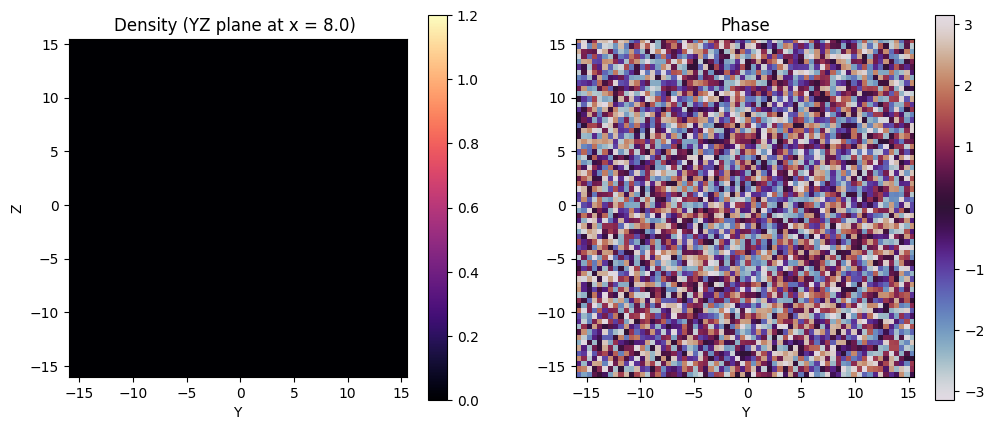

In [22]:
time_history = []
energy_history = []
atom_history = []

n_frames = 300
steps_per_frame = 100
save_every = 20

idx_x_soliton = int(3 * pts[0] / 4)

psi_slice_init = wfn.component[idx_x_soliton, :, :].get()

fig, (ax_dens, ax_phase) = plt.subplots(1, 2, figsize=(12, 5))

im_dens = ax_dens.imshow(np.abs(psi_slice_init)**2, 
                         extent=[Y.min(), Y.max(), Z.min(), Z.max()],
                         cmap='magma', origin='lower', vmin=0, vmax=1.2)
ax_dens.set_title(fr"Density (YZ plane at x = {x_c2:.1f}) ")
ax_dens.set_xlabel("Y")
ax_dens.set_ylabel("Z")
plt.colorbar(im_dens, ax=ax_dens)

im_phase = ax_phase.imshow(np.angle(psi_slice_init), 
                           extent=[Y.min(), Y.max(), Z.min(), Z.max()],
                           cmap='twilight', origin='lower', vmin=-np.pi, vmax=np.pi)
ax_phase.set_title(fr"Phase")
ax_phase.set_xlabel("Y")
plt.colorbar(im_phase, ax=ax_phase)

In [23]:
def update(frame):
    t_start_frame = frame * steps_per_frame * dt
    for s in range(steps_per_frame):
        step_wavefunction(wfn, params)
        if s % save_every == 0:
            psi = wfn.component
            dens = cp.abs(psi)**2
            
            # Numero totale atomi (N = \int |\psi|^2 dV)
            N = cp.sum(dens) * dV
            
            # Energia Cinetica (Spazio K)
            psi_k = cp.fft.fftn(psi)
            E_kin = 0.5 * cp.sum(K2 * cp.abs(psi_k)**2) * dV / (pts[0] * pts[1] * pts[2])
            
            # Energia di Interazione (g/2 * \int |\psi|^4 dV)
            E_int = 0.5 * g * cp.sum(dens**2) * dV
            
            current_t = t_start_frame + (s * dt)
            time_history.append(current_t)
            atom_history.append(float(N.get()))
            energy_history.append(float((E_kin + E_int).get()))
    
    psi_slice_gpu = wfn.component[idx_x_soliton, :, :]
    psi_slice_cpu = psi_slice_gpu.get()
    
    im_dens.set_data(np.abs(psi_slice_cpu)**2)
    im_phase.set_data(np.angle(psi_slice_cpu))
    
    current_time = (frame + 1) * steps_per_frame * dt
    fig.suptitle(f"t = {current_time:.2f}", fontsize=14)
    
    return [im_dens, im_phase]

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)

output_file = "dark_solitons_3d/ds3d.html"
ani.save(output_file, writer='html')

plt.close(fig)

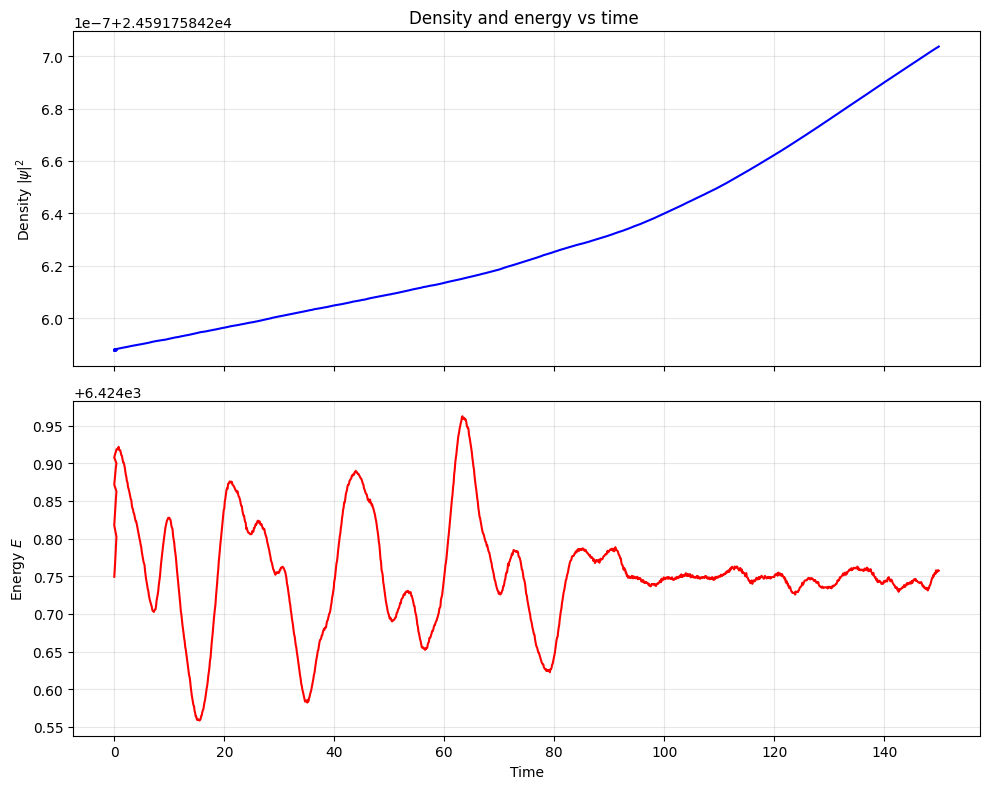

In [24]:
fig_stats, (ax_at, ax_en) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_at.plot(time_history, atom_history, color='blue', lw=1.5)
ax_at.set_title("Density and energy vs time ")
ax_at.set_ylabel(r"Density $|\psi|^2$")
ax_at.grid(True, alpha=0.3)

ax_en.plot(time_history, energy_history, color='red', lw=1.5)
ax_en.set_xlabel("Time")
ax_en.set_ylabel("Energy $E$")
ax_en.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dark_solitons_3d/te_ds3d.pdf")
plt.show()